In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from functools import reduce
import matplotlib.dates as mdates
from matplotlib.dates import HourLocator, MonthLocator, YearLocator, MinuteLocator
import datetime

In [2]:
# PC filepath
filepath = "D:/dissertation-data"

#Laptop filepath
#filepath = "C:/Users/Giancarlo/Desktop/dissertation-data"

# Linear Order Book

## Parameters

In [3]:
'''
# To mimic SUSHI on 11.08:
beta, alpha          = 0.1, 0.1  # spread from mid to best bid (beta) and mid to best ask (alpha)
worst_bid, worst_ask = 10, 10 # max deviation from midpoint for bid and ask side
bid_depth, ask_depth = 2_200_000, 1_800_000 # Cumulative size of bids and asks in tokens - SUSHI: 2.2M, 1.8M
max_deviation        = 12    # determines range of x-axis
tick_size            = 0.1  # theta ; cannot be larger than beta or alpha
''';

In [49]:
# To mimic ETH on 20.08:
beta, alpha          = 0, 0  
worst_bid, worst_ask = 0.6, 0.6 
bid_depth, ask_depth = 17_000, 17_000 
max_deviation        = 0.7    
tick_size            = 0.00005

## Building dataframe

Getting prerequisites

In [50]:
total_ticks = int(max_deviation/tick_size)

# Find how many prices have an existing bid/ask
bid_ticks = round((worst_bid-beta)/tick_size)
ask_ticks = round((worst_ask-alpha)/tick_size)

# Find how many ticks to skip at beginning, because they belong to spread
beta_ticks = round(beta/tick_size)
alpha_ticks = round(alpha/tick_size)

# Find necessary size of bid/ask to have constant size at all prices
bid_size = bid_depth/bid_ticks
ask_size = ask_depth/ask_ticks

print(f'Total ticks: {total_ticks}\n')
print(f"Beta ticks: {beta_ticks} \nAlpha ticks: {alpha_ticks}\n")
print(f"Bid ticks: {bid_ticks} \nAsk ticks: {ask_ticks}\n")
print(f"Bid size: {bid_size} \nAsk size: {ask_size}\n")

Total ticks: 13999

Beta ticks: 0 
Alpha ticks: 0

Bid ticks: 12000 
Ask ticks: 12000

Bid size: 1.4166666666666667 
Ask size: 1.4166666666666667



Assembling df

In [51]:
pd.set_option('display.max_rows', 50) # default = 50

# Setting up df with prices and all sizes = 0
orderbook = pd.DataFrame(
    {
    'price': np.linspace(0, max_deviation, total_ticks), 
    'bid_size': np.zeros(total_ticks), 
    'ask_size': np.zeros(total_ticks),
    })

# Replace the sizes for those prices where bids/asks are present
orderbook.loc[beta_ticks+1:bid_ticks+beta_ticks, 'bid_size'] = bid_size
orderbook.loc[alpha_ticks+1 : ask_ticks+alpha_ticks, 'ask_size'] = ask_size

# Add cumulative size columns
orderbook['cumulative_bid'] = orderbook['bid_size'].cumsum()
orderbook['cumulative_ask'] = orderbook['ask_size'].cumsum()

In [52]:
orderbook

,price,bid_size,ask_size,cumulative_bid,cumulative_ask
0,0.00000,0.000000,0.000000,0.000000,0.000000
1,0.00005,1.416667,1.416667,1.416667,1.416667
2,0.00010,1.416667,1.416667,2.833333,2.833333
3,0.00015,1.416667,1.416667,4.250000,4.250000
4,0.00020,1.416667,1.416667,5.666667,5.666667
...,...,...,...,...,...
13994,0.69980,0.000000,0.000000,17000.000000,17000.000000
13995,0.69985,0.000000,0.000000,17000.000000,17000.000000
13996,0.69990,0.000000,0.000000,17000.000000,17000.000000
13997,0.69995,0.000000,0.000000,17000.000000,17000.000000


# Test: Look up price effect of given transaction size

In [53]:
test_delta = -900_000

nearest_depth = orderbook[orderbook['cumulative_bid'] <= -test_delta]['cumulative_bid'].max()
corresponding_price = orderbook.loc[orderbook['cumulative_bid'] == nearest_depth, 'price'].iloc[0]

In [54]:
nearest_depth

16999.999999997723

In [55]:
corresponding_price

0.6000857265323617

## Plot

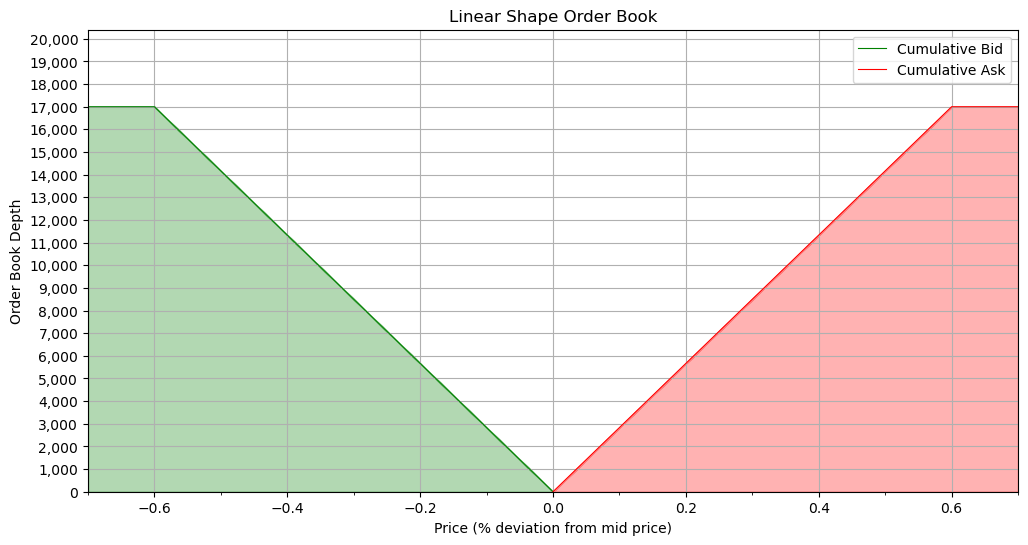

In [65]:
# setting x's and y's for the plot
x_bid = orderbook['price'].multiply(-1)
y_bid = orderbook['cumulative_bid']

x_ask = orderbook['price']
y_ask = orderbook['cumulative_ask']

# Create plot
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

# Plot the bids in green
plt.plot(x_bid, y_bid, color='green', label='Cumulative Bid', drawstyle="steps", linewidth=0.8)
# Plot the asks in red
plt.plot(x_ask, y_ask, color='red', label='Cumulative Ask', drawstyle="steps", linewidth=0.8)

# Fill area under bids and asks with colour
plt.fill_between(x_bid, y_bid, step="pre", alpha=0.3, color='green')
plt.fill_between(x_ask, y_ask, step="pre", alpha=0.3, color='red')

# Add labels and title
plt.xlabel('Price (% deviation from mid price)')
plt.ylabel('Order Book Depth')
plt.title('Linear Shape Order Book')

# Axis options
#plt.xticks(np.arange(-max_deviation, max_deviation+tick_size), rotation=70)
plt.xticks(np.arange(-max_deviation, max_deviation+tick_size, tick_size*2000), minor=True)

# Set distance between ticks on y-axis
max_depth = max(bid_depth, ask_depth)

if max_depth >= 500_000:
    y_tick_step = 100_000
elif max_depth >= 50_000:
    y_tick_step = 10_000
elif max_depth >= 10_000:
    y_tick_step = 1_000
elif max_depth >= 5_000:
    y_tick_step = 1_000
else:
    y_tick_step = 100

plt.yticks(np.arange(0, max_depth*1.2, y_tick_step))
# Format y ticks as full number with thousands separator
axes.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.xlim(min(x_bid), max(x_ask))
plt.ylim(0, max(max(y_bid), max(y_ask))*1.2)

# Add a legend to differentiate the plots and grid
plt.legend()
plt.grid()

# Show the plot
plt.show()

# Simulation

In [66]:
def get_column_names(dataname):
    # Returns a list with the column names corresponding to the chosen dataname
    # Used within 'load_raw_data' function
    if dataname=="aggTrade":
        Columns = {   
          "data.e": "Event_type",
          "data.E": "Event_time", 
          "data.s": "Symbol", 
          "data.a": "Aggregate_trade_ID",
          "data.p": "Price",  
          "data.q": "Quantity",
          "data.f": "First_trade_ID",
          "data.l": "Last_trade_ID",
          "data.T": "Trade_time",
          "data.m": "buyer_maker_flag",
          "data.M": "Ignore"
        }  

    elif dataname=="bookTicker":
        Columns = {  
          "data.u": "updateId",  
          "data.s": "symbol",  
          "data.b": "best_bid",
          "data.B": "best_bid_qty",
          "data.a": "best_ask",  
          "data.E": "Event_time",
          "data.T": "Trade_time",
          "data.A": "best_ask_qty" 
        }  

    elif dataname=="trade":
        Columns = {  
          "data.e": "Event_type",
          "data.E": "Event_time",
          "data.s": "Symbol",  
          "data.t": "Trade_ID",  
          "data.p": "Price",  
          "data.q": "Quantity",  
          "data.b": "Buyer_order_ID",  
          "data.a": "Seller order ID",  
          "data.T": "Trade_time", 
          "data.m": "buyer_maker_flag",
          "data.M": "Ignore"
        } 
    else:
        Columns = {}
        # raise Exception(f"dataname {dataname} in function get_column_names not found")
        
    return Columns

In [12]:
def load_raw_data(filepath, tradevenue, ticker, timestamp, dataname):
    # Loads the specified data
    filename = f"{filepath}/{tradevenue}/{timestamp}/{dataname}/{tradevenue}_{ticker}_{dataname}_{timestamp}.csv.gz"
    
    if os.path.exists(filename):
        # Get column names from previous function
        colnames = get_column_names(dataname)
        # Read data, drop 'unnamed' column and rename remaining columns
        df = (pd
              .read_csv(filename, compression='gzip', index_col=False)
              .drop(columns=['Unnamed: 0'])
              .rename(columns=colnames)
              )
        
        # Convert timestamps to datetime format
        for col in ["Event_time", "Trade_time"]:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], unit = "ms")
            
    
        return df, df.iloc[:100_000]
    
    else:
        raise Exception(f"{filename} doesn't exist in location")

In [13]:
def resample_data(df, token, time_interval='1T'):
    df2 = (df
             .assign(timestamp = lambda df: df.Event_time)
             .assign(latency = lambda df: ((df.Event_time-df.Trade_time).dt.total_seconds()).astype(int)/1000)
             .rename(columns={'Price':'price'})
             .loc[:, ["timestamp", "price", "latency"]]
             .sort_values("timestamp")
             .set_index("timestamp")
             .resample(time_interval, closed="right", label="right")
             .last()
             .reset_index(drop=False)
             .rename(columns = lambda x: f"{token}_{x}" if x != "timestamp" else x)
             )
    return df2

# Load raw data, reduce to minute

In [14]:
'''
# Load raw data files
sushiup, sushiup_     = load_raw_data(filepath, "binance", "sushiupusdt", "2021-05-19", "trade")
sushidown, sushidown_ = load_raw_data(filepath, "binance", "sushidownusdt", "2021-05-19", "trade")
sushi, sushi_         = load_raw_data(filepath, "binance-futures", "sushiusdt", "2021-05-19", "trade")
''';

In [15]:

# Load ETH data files
sushiup, sushiup_     = load_raw_data(filepath, "binance", "ethupusdt", "2021-05-19", "trade")
sushidown, sushidown_ = load_raw_data(filepath, "binance", "ethdownusdt", "2021-05-19", "trade")
sushi, sushi_         = load_raw_data(filepath, "binance-futures", "ethusdt", "2021-05-19", "trade")


In [16]:
# Reduce data to minute instead of ms
sushiup_minute   = resample_data(sushiup, 'sushiup', '1T')
sushidown_minute = resample_data(sushidown, 'sushidown', '1T')
sushi_minute     = resample_data(sushi, 'sushi', '1T')

In [17]:
sushiup_minute

,timestamp,sushiup_price,sushiup_latency
0,2021-05-19 00:01:00,329.387,0.0
1,2021-05-19 00:02:00,326.296,0.0
2,2021-05-19 00:03:00,325.482,0.0
3,2021-05-19 00:04:00,326.012,0.0
4,2021-05-19 00:05:00,324.677,0.0
...,...,...,...
1435,2021-05-19 23:56:00,70.950,0.0
1436,2021-05-19 23:57:00,71.582,0.0
1437,2021-05-19 23:58:00,70.930,0.0
1438,2021-05-19 23:59:00,69.878,0.0


In [18]:
# merge the minute data to one df
sushi_merged = reduce(lambda left, right: pd.merge(left, right, on="timestamp"), 
                      [sushiup_minute, sushidown_minute, sushi_minute])

In [19]:
sushi_merged

,timestamp,sushiup_price,sushiup_latency,sushidown_price,sushidown_latency,sushi_price,sushi_latency
0,2021-05-19 00:01:00,329.387,0.0,0.000642,0.0,3382.76,0.0
1,2021-05-19 00:02:00,326.296,0.0,0.000651,0.0,3367.54,0.0
2,2021-05-19 00:03:00,325.482,0.0,0.000652,0.0,3359.14,0.0
3,2021-05-19 00:04:00,326.012,0.0,0.000647,0.0,3372.75,0.0
4,2021-05-19 00:05:00,324.677,0.0,0.000653,0.0,3359.34,0.0
...,...,...,...,...,...,...,...
1435,2021-05-19 23:56:00,70.950,0.0,0.000178,0.0,2478.09,0.0
1436,2021-05-19 23:57:00,71.582,0.0,0.000177,0.0,2484.75,0.0
1437,2021-05-19 23:58:00,70.930,0.0,0.000180,0.0,2465.44,0.0
1438,2021-05-19 23:59:00,69.878,0.0,0.000181,0.0,2452.65,0.0


# Import Rebalance Data

In [20]:
'''
# Get rebalancing data from Excel

timestamp = datetime.date(2021,5,19)
excelfile = f"{filepath}/Leverage Tokens/BinanceLeverageToken.xlsx"

sushiup_excel = pd.read_excel(excelfile, sheet_name="SushiUp", usecols = "A:H")
sushidown_excel = pd.read_excel(excelfile, sheet_name="SushiDown", usecols = "A:H")

columns = ["BasketBefore", "BasketAfter", "LeverageBefore", "LeverageAfter", "TokensBefore"]


# Clean data and convert to float - why only on sushiup?
for col in columns:
    sushiup_excel[col]  = sushiup_excel[col].str.replace('\xa0', '', regex=True)
    sushiup_excel[col]  = sushiup_excel[col].str.replace('+', '', regex=True)
    sushiup_excel[col]  = sushiup_excel[col].str.replace(',', '', regex=True).astype(float)


sushiup_excel = (sushiup_excel
         # .loc[lambda df: df.Time.dt.date == timestamp]
         .sort_values(["Time"])
         .reset_index(drop=True)
         )

sushidown_excel = (sushidown_excel
         # .loc[lambda df: df.Time.dt.date == timestamp]
         .sort_values(["Time"])
         .reset_index(drop=True)
         )
''';

In [21]:

# Get ETH rebalancing data from Excel

timestamp = datetime.date(2021,5,19)
excelfile = f"{filepath}/Leverage Tokens/BinanceLeverageToken.xlsx"

sushiup_excel = pd.read_excel(excelfile, sheet_name="EthUp", usecols = "A:H")
sushidown_excel = pd.read_excel(excelfile, sheet_name="EthDown", usecols = "A:H")

columns = ["BasketBefore", "BasketAfter", "LeverageBefore", "LeverageAfter", "TokensBefore"]


# Clean data and convert to float - why only on sushiup?
for col in columns:
    sushiup_excel[col]  = sushiup_excel[col].str.replace('\xa0', '', regex=True)
    sushiup_excel[col]  = sushiup_excel[col].str.replace('+', '', regex=True)
    sushiup_excel[col]  = sushiup_excel[col].str.replace(',', '', regex=True).astype(float)


sushiup_excel = (sushiup_excel
         # .loc[lambda df: df.Time.dt.date == timestamp]
         .sort_values(["Time"])
         .reset_index(drop=True)
         )

sushidown_excel = (sushidown_excel
         # .loc[lambda df: df.Time.dt.date == timestamp]
         .sort_values(["Time"])
         .reset_index(drop=True)
         )


In [22]:
# merge Excel data to the prices
sushi_merged = (pd
        .merge_asof(sushi_merged, sushiup_excel[["Time", 'BasketAfter', 'TokensAfter']], left_on="timestamp", right_on="Time")
        .rename(columns={"BasketAfter": "BastketUP", 'TokensAfter': "nTokensUP"})
        )

sushi_merged = (pd
        .merge_asof(sushi_merged, sushidown_excel[["Time", 'BasketAfter', 'TokensAfter']], left_on="timestamp", right_on="Time")
        .rename(columns={"BasketAfter": "BastketDOWN", 'TokensAfter': "nTokensDOWN"})
        )

In [23]:
sushi_merged

,timestamp,sushiup_price,sushiup_latency,sushidown_price,sushidown_latency,sushi_price,sushi_latency,Time_x,BastketUP,nTokensUP,Time_y,BastketDOWN,nTokensDOWN
0,2021-05-19 00:01:00,329.387,0.0,0.000642,0.0,3382.76,0.0,2021-05-05 23:58:29,34204.181,175537.32,2021-04-23 16:47:25,-5822.64,2.311824e+09
1,2021-05-19 00:02:00,326.296,0.0,0.000651,0.0,3367.54,0.0,2021-05-05 23:58:29,34204.181,175537.32,2021-04-23 16:47:25,-5822.64,2.311824e+09
2,2021-05-19 00:03:00,325.482,0.0,0.000652,0.0,3359.14,0.0,2021-05-05 23:58:29,34204.181,175537.32,2021-04-23 16:47:25,-5822.64,2.311824e+09
3,2021-05-19 00:04:00,326.012,0.0,0.000647,0.0,3372.75,0.0,2021-05-05 23:58:29,34204.181,175537.32,2021-04-23 16:47:25,-5822.64,2.311824e+09
4,2021-05-19 00:05:00,324.677,0.0,0.000653,0.0,3359.34,0.0,2021-05-05 23:58:29,34204.181,175537.32,2021-04-23 16:47:25,-5822.64,2.311824e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,2021-05-19 23:56:00,70.950,0.0,0.000178,0.0,2478.09,0.0,2021-05-19 14:54:08,20339.314,410067.05,2021-05-19 14:35:25,-5092.79,1.598841e+10
1436,2021-05-19 23:57:00,71.582,0.0,0.000177,0.0,2484.75,0.0,2021-05-19 14:54:08,20339.314,410067.05,2021-05-19 14:35:25,-5092.79,1.598841e+10
1437,2021-05-19 23:58:00,70.930,0.0,0.000180,0.0,2465.44,0.0,2021-05-19 14:54:08,20339.314,410067.05,2021-05-19 14:35:25,-5092.79,1.598841e+10
1438,2021-05-19 23:59:00,69.878,0.0,0.000181,0.0,2452.65,0.0,2021-05-19 14:54:08,20339.314,410067.05,2021-05-19 14:35:25,-5092.79,1.598841e+10


In [24]:
# Add leverageUP and leverageDOWN to sushi_merged

sushi_merged2 = (sushi_merged
             .assign(leverageUP   = lambda df: (df.BastketUP*df.sushi_price)/(df.nTokensUP*df.sushiup_price))
             .assign(leverageDOWN = lambda df: -(df.BastketDOWN*df.sushi_price)/(df.nTokensDOWN*df.sushidown_price))
             )

# Reduce to given time-frame

In [25]:
# Keep only data for hours to be analysed

plotstartS = datetime.datetime(2021,5,19, 12,0,0)
plotendS   = datetime.datetime(2021,5,19, 14,0,0)


indx = (sushi_merged2.timestamp>=plotstartS) & (sushi_merged2.timestamp<=plotendS)
sushi_merged3 = sushi_merged2.loc[indx]

In [26]:
sushi_merged3

,timestamp,sushiup_price,sushiup_latency,sushidown_price,sushidown_latency,sushi_price,sushi_latency,Time_x,BastketUP,nTokensUP,Time_y,BastketDOWN,nTokensDOWN,leverageUP,leverageDOWN
719,2021-05-19 12:00:00,208.109,0.0,0.000980,0.0,2723.82,0.000,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 02:36:21,-10869.20,1.809539e+10,2.550335,1.669482
720,2021-05-19 12:01:00,205.512,0.0,0.000988,0.0,2722.41,0.000,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 02:36:21,-10869.20,1.809539e+10,2.581226,1.655107
721,2021-05-19 12:02:00,207.101,0.0,0.000983,0.0,2723.49,0.000,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 02:36:21,-10869.20,1.809539e+10,2.562438,1.664186
722,2021-05-19 12:03:00,208.160,0.0,0.000970,0.0,2736.86,0.000,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 02:36:21,-10869.20,1.809539e+10,2.561917,1.694768
723,2021-05-19 12:04:00,210.408,0.0,0.000950,0.0,2754.92,0.000,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 02:36:21,-10869.20,1.809539e+10,2.551270,1.741867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,2021-05-19 13:56:00,67.630,0.0,0.000210,0.0,2248.70,2.123,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 13:51:20,-26231.81,1.556140e+10,6.478909,18.050606
836,2021-05-19 13:57:00,64.000,0.0,0.000209,0.0,2311.00,0.676,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 13:51:20,-26231.81,1.556140e+10,7.036063,18.639455
837,2021-05-19 13:58:00,66.655,0.0,0.000209,0.0,2266.66,0.538,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 13:51:20,-26231.81,1.556140e+10,6.626182,18.281829
838,2021-05-19 13:59:00,71.020,0.0,0.000202,0.0,NaN,NaN,2021-05-05 23:58:29,34204.181,175537.32,2021-05-19 13:51:20,-26231.81,1.556140e+10,NaN,NaN


# Simulate tokens

In [67]:
# Simulation
def token_characteristics(price, investment, lambda_target, lambda_up, lambda_down, lambda_0, 
                          rebalance, use_orderbook = False):
    # Begin Simulation
    
    price_array = price.copy() #prevent price array from being overwritten
    nvars = 8 # v, x, x*, lambda, lambda*, delta, price_multiplier
    out = np.empty((len(price_array), nvars*2))
    omegas = np.array([1,-1])

    # initialize the variables at time t=0
    # for omega=1 the first 7 columns are filled, and for omega=-1 the last 7
    for i in range(len(omegas)):
        omega = omegas[i]
        out[0,i*nvars+0] = investment # v
        out[0,i*nvars+1] = omega*investment*lambda_0 # x
        out[0,i*nvars+2] = omega*investment*lambda_0 # x_star
        out[0,i*nvars+3] = omega*out[0,i*nvars+1]/out[0,i*nvars+0] # lambda = omega*x/v
        out[0,i*nvars+4] = out[0,i*nvars+3] # lambda_star
        out[0,i*nvars+5] = 0 # delta
        out[0,i*nvars+6] = 1 # price multiplier
        out[0,i*nvars+7] = 1 # omega*investment*lambda_0
        

    # update variables over time
    for t in range(1,len(out)):
        
        #apply price multiplier
        if use_orderbook == True:
            price_array[t] = price_array[t] * out[t-1,i*nvars+6]
        
        # get return for the current time step
        ret = price_array[t]/price_array[t-1]-1
        for i in range(len(omegas)):
            omega = omegas[i]
            out[t,i*nvars+0] = out[t-1,i*nvars+0] * (1 + omega * out[t-1, i*nvars+4] * ret) # v
            out[t,i*nvars+1] = out[t-1,i*nvars+2] * (1+ret) # x
            out[t,i*nvars+3] = omega * out[t,i*nvars+1] / out[t,i*nvars+0]  # lambda

            # x_star
            # check whether rebalancing is required
            if lambda_down <= out[t, i*nvars+3] <= lambda_up:
                out[t, i*nvars+2] = out[t,i*nvars+1] # if no rebalance, x_star = x
            else: # rebalance back to target
                if rebalance=="boundary":
                    if lambda_down >= out[t, i*nvars+3]: # rebalance from below
                        out[t, i*nvars+2] = omega*out[t,i*nvars+0]*lambda_down # x_star = omega*v*target_lambda (lower)
                    elif lambda_up <= out[t, i*nvars+3]: # rebalance from above
                        out[t, i*nvars+2] = omega*out[t,i*nvars+0]*lambda_up # x_star = omega*v*target_lambda (upper)
                elif rebalance=="target":
                    out[t, i*nvars+2] = omega*out[t,i*nvars+0]*lambda_target

            out[t,i*nvars+4] = omega * out[t, i*nvars+2] / out[t,i*nvars+0] # lambda_star
            out[t,i*nvars+5] = out[t, i*nvars+2] - out[t,i*nvars+1] # delta = x_star - x in $ - convert to sushi
            
            if use_orderbook == True:
                # Convert notional delta to tokens
                delta_tokens = out[t,i*nvars+5] / price_array[t] # Need to use token price, not underlying price?

                # Use delta and orderbook to find price effect
                # With positive delta, no change necessary
                if delta_tokens > 0:
                    nearest_depth = orderbook[orderbook['cumulative_bid'] <= delta_tokens]['cumulative_bid'].max()
                    price_difference = orderbook.loc[orderbook['cumulative_bid'] == nearest_depth, 'price'].iloc[0]
                    out[t,i*nvars+6] = out[t-1,i*nvars+6] * (1+price_difference)

                # With negative delta need to make positive, look up, then convert to negative again
                elif delta_tokens < 0:
                    nearest_depth = orderbook[orderbook['cumulative_bid'] <= -delta_tokens]['cumulative_bid'].max()
                    price_difference = orderbook.loc[orderbook['cumulative_bid'] == nearest_depth, 'price'].iloc[0]
                    out[t,i*nvars+6] = out[t-1,i*nvars+6] * (1-price_difference)

                else:
                    out[t,i*nvars+6] = out[t-1,i*nvars+6]

            else:
                out[t,i*nvars+6] = out[t-1,i*nvars+6]

            
    tk = pd.DataFrame(out, columns=["v_up", "x_up", "xst_up", "lambda_up", 
                                    "lambdast_up", "delta_up", "price_effect_up", 
                                    "v_down", "x_down", "xst_down", "lambda_down", 
                                    "lambdast_down", "delta_down", "price_effect_down"])
    
    return(tk)#, price_differences)



In [78]:
# Parameters (same for up and down)
lambda_target = 3 # Only used when rebalance = 'target'
lambda_up     = 4 # upper boundary
lambda_down   = 1.25 # lower boundary
#lambda_0      = 3.5 # Leverage at start
rebalance     = "boundary" # either 'boundary' or 'target'

price         = np.array(sushi_merged3["sushi_price"].values)

In [79]:
# UP parameters

#up_investment  = sushi_merged3["sushiup_price"].iloc[0]
up_investment = 259_984#6_551_077.19 # Number of SUSHIUP issued on 19.05.2021
up_lambda_0    = sushi_merged3["leverageUP"].iloc[0]

In [80]:
# DOWN parameters

#down_investment  = sushi_merged3["sushidown_price"].iloc[0]
down_investment = 15_988_409_170#125_716_067.04 # Number of SUSHIDOWN issued on 19.05.2021; number kept changing
down_lambda_0    = sushi_merged3["leverageDOWN"].iloc[0]

In [81]:
# Simulating Tokens with and without rebalances

# UP
tk_up       = token_characteristics(price, up_investment, lambda_target, 
                                    lambda_up, lambda_down, up_lambda_0, rebalance)
tk_up_ob    = token_characteristics(price, up_investment, lambda_target, 
                                    lambda_up, lambda_down, up_lambda_0, rebalance, use_orderbook=True)
tk_up_unc   = token_characteristics(price, up_investment, lambda_target, 
                                    100_000, -100_000, up_lambda_0, rebalance)

# DOWN
tk_down     = token_characteristics(price, down_investment, lambda_target, 
                                    lambda_up, lambda_down, down_lambda_0, rebalance)
tk_down_ob  = token_characteristics(price, down_investment, lambda_target, 
                                    lambda_up, lambda_down, down_lambda_0, rebalance, use_orderbook=True)
tk_down_unc = token_characteristics(price, down_investment, lambda_target, 
                                    100_000, -100_000, down_lambda_0, rebalance)

In [86]:
#tk_up.loc[(tk_up['delta_up'] != 0) & pd.notna(tk_up['lambda_up'])]
tk_down#[0].delta_down#.loc[100:120]#.describe()

,v_up,x_up,xst_up,lambda_up,lambdast_up,delta_up,price_effect_up,v_down,x_down,xst_down,lambda_down,lambdast_down,delta_down,price_effect_down
0,1.598841e+10,2.669237e+10,2.669237e+10,1.669482,1.669482,0.0,1.0,1.598841e+10,-2.669237e+10,-2.669237e+10,1.669482,1.669482,0.0,1.0
1,1.597459e+10,2.667855e+10,2.667855e+10,1.670061,1.670061,0.0,1.0,1.600223e+10,-2.667855e+10,-2.667855e+10,1.667177,1.667177,0.0,1.0
2,1.598518e+10,2.668913e+10,2.668913e+10,1.669618,1.669618,0.0,1.0,1.599164e+10,-2.668913e+10,-2.668913e+10,1.668943,1.668943,0.0,1.0
3,1.611620e+10,2.682015e+10,2.682015e+10,1.664174,1.664174,0.0,1.0,1.586062e+10,-2.682015e+10,-2.682015e+10,1.690990,1.690990,0.0,1.0
4,1.629318e+10,2.699714e+10,2.699714e+10,1.656960,1.656960,0.0,1.0,1.568364e+10,-2.699714e+10,-2.699714e+10,1.721356,1.721356,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,1.133242e+10,2.203638e+10,2.203638e+10,1.944543,1.944543,0.0,1.0,1.233358e+10,-4.207220e+10,-4.207220e+10,3.411191,3.411191,0.0,1.0
117,1.194294e+10,2.264689e+10,2.264689e+10,1.896259,1.896259,0.0,1.0,1.116797e+10,-4.323781e+10,-4.323781e+10,3.871589,3.871589,0.0,1.0
118,1.150842e+10,2.221238e+10,2.221238e+10,1.930098,1.930098,0.0,1.0,1.199756e+10,-4.240823e+10,-4.240823e+10,3.534739,3.534739,0.0,1.0
119,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [87]:
pd.set_option('display.max_rows', 130) # default = 50
tk_down_ob#[1]#.loc[100:120]

,v_up,x_up,xst_up,lambda_up,lambdast_up,delta_up,price_effect_up,v_down,x_down,xst_down,lambda_down,lambdast_down,delta_down,price_effect_down
0,1.598841e+10,2.669237e+10,2.669237e+10,1.669482,1.669482,0.000000e+00,1.000000,1.598841e+10,-2.669237e+10,-2.669237e+10,1.669482,1.669482,0.000000e+00,1.000000e+00
1,1.597459e+10,2.667855e+10,2.667855e+10,1.670061,1.670061,0.000000e+00,1.000000,1.600223e+10,-2.667855e+10,-2.667855e+10,1.667177,1.667177,0.000000e+00,1.000000e+00
2,1.598518e+10,2.668913e+10,2.668913e+10,1.669618,1.669618,0.000000e+00,1.000000,1.599164e+10,-2.668913e+10,-2.668913e+10,1.668943,1.668943,0.000000e+00,1.000000e+00
3,1.611620e+10,2.682015e+10,2.682015e+10,1.664174,1.664174,0.000000e+00,1.000000,1.586062e+10,-2.682015e+10,-2.682015e+10,1.690990,1.690990,0.000000e+00,1.000000e+00
4,1.629318e+10,2.699714e+10,2.699714e+10,1.656960,1.656960,0.000000e+00,1.000000,1.568364e+10,-2.699714e+10,-2.699714e+10,1.721356,1.721356,0.000000e+00,1.000000e+00
5,1.635531e+10,2.705927e+10,2.705927e+10,1.654464,1.654464,0.000000e+00,1.000000,1.562151e+10,-2.705927e+10,-2.705927e+10,1.732180,1.732180,0.000000e+00,1.000000e+00
6,1.632757e+10,2.703153e+10,2.703153e+10,1.655576,1.655576,0.000000e+00,1.000000,1.564924e+10,-2.703153e+10,-2.703153e+10,1.727338,1.727338,0.000000e+00,1.000000e+00
7,1.636795e+10,2.707191e+10,2.707191e+10,1.653958,1.653958,0.000000e+00,1.000000,1.560887e+10,-2.707191e+10,-2.707191e+10,1.734392,1.734392,0.000000e+00,1.000000e+00
8,1.627524e+10,2.697920e+10,2.697920e+10,1.657683,1.657683,0.000000e+00,1.000000,1.570157e+10,-2.697920e+10,-2.697920e+10,1.718248,1.718248,0.000000e+00,1.000000e+00
9,1.625966e+10,2.696362e+10,2.696362e+10,1.658314,1.658314,0.000000e+00,1.000000,1.571716e+10,-2.696362e+10,-2.696362e+10,1.715553,1.715553,0.000000e+00,1.000000e+00


In [84]:
print(tk_down_ob['price_effect_down'].min())
print(tk_up_ob['price_effect_up'].min())

1.3730404970419647e-28
0.9933143062494914


# Plot Simulations

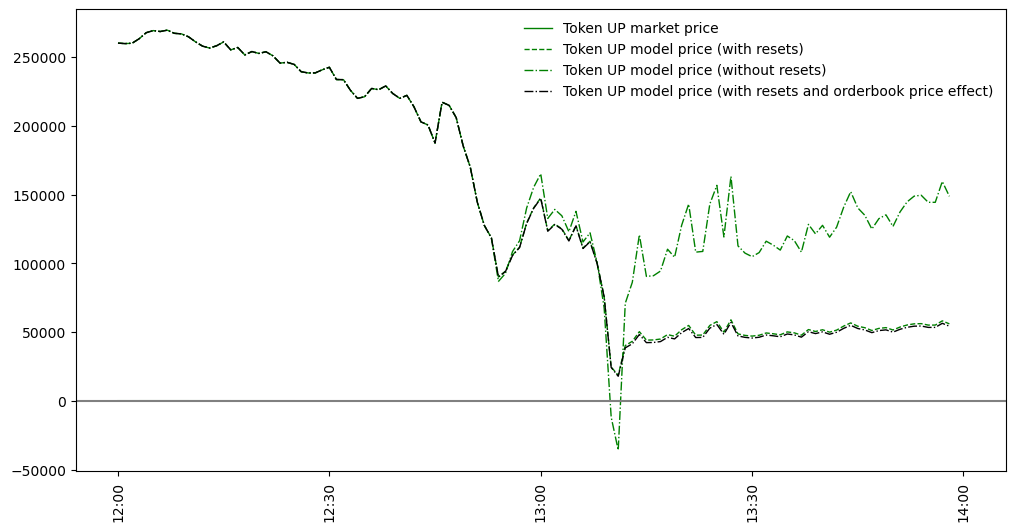

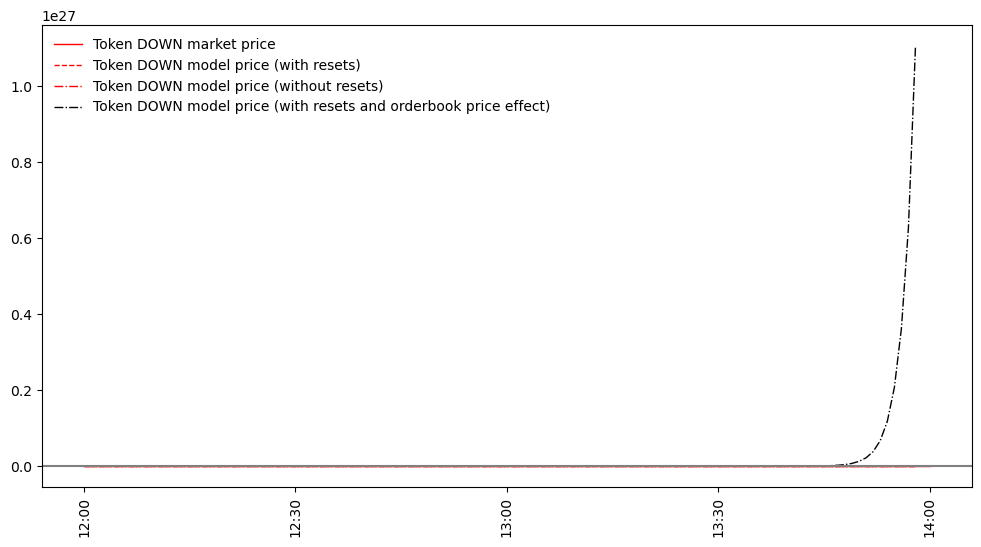

In [85]:
# Plot
for token in ['UP', 'DOWN']:
    
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6), sharex=False, sharey=False)

    axes.spines['top'].set_visible(True)
    axes.spines['right'].set_visible(True)
    axes.spines['bottom'].set_visible(True)
    axes.spines['left'].set_visible(True)

    label = f"Token {token} market price"
    label2 = f"Token {token} model price (with resets)"
    label3 = f"Token {token} model price (without resets)"
    label4 = f"Token {token} model price (with resets and orderbook price effect)"
    x = sushi_merged3.timestamp
    y = sushi_merged3[f"sushi{token.lower()}_price"]
    y2 = sushi_merged3[f"leverage{token}"] # Y values for reported rebalances
    vt = tk_up.v_up if token=="UP" else  tk_down.v_down # Y values for simulated rebalances
    vt_unc = tk_up_unc.v_up if token=="UP" else  tk_down_unc.v_down # Y values with no rebalances
    vt_ob = tk_up_ob.v_up if token=="UP" else  tk_down_ob.v_down  # Y values with orderbook price effect

    lambdat = tk_up.lambda_up if token=="UP" else  tk_down.lambda_down
    color = "green" if token=="UP" else "red"

    # plot the data
    axes.plot(x,y, label=label,  color=color, marker=None, linewidth = 1, ls = '-')
    axes.plot(x,vt, label=label2, color=color, marker=None, linewidth = 1, ls = '--')
    axes.plot(x,vt_unc, label=label3, color=color, marker=None, linewidth = 1, ls = '-.')
    axes.plot(x,vt_ob, label=label4, color='k', marker=None, linewidth = 1, ls = '-.')

    # format the x-axis
    axes.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    axes.xaxis.set_major_locator(MinuteLocator(byminute=[0, 30], interval=1))
    plt.xticks(rotation=90)
    plt.axhline(y=0, color='grey', linestyle='-')

    # # ask matplotlib for the plotted objects and their labels
    lines, labels = axes.get_legend_handles_labels()
    axes.legend(lines, labels, loc='upper right' if token=="UP" else 'upper left', frameon=False)

    plt.show()

<Axes: >

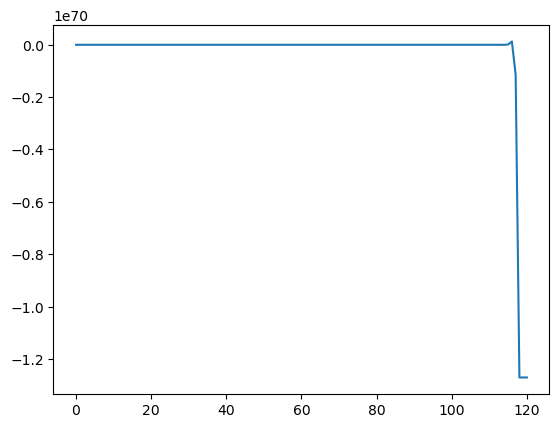

In [36]:
tk_down_ob['price_effect_down'].plot()

<Axes: >

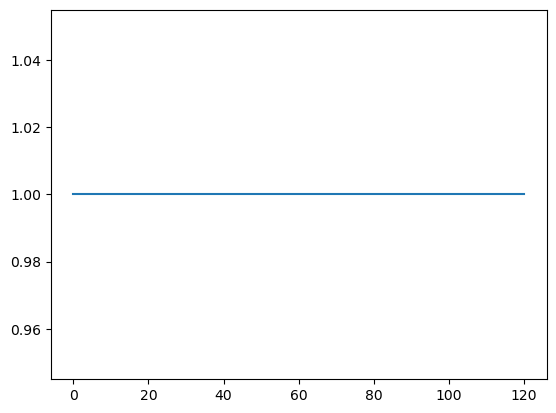

In [37]:
tk_up_ob['price_effect_up'].plot()

In [38]:
tk_down.loc[550:599]
sushidown.loc[sushidown['Price'].isna()]

,stream,local_timestamp,Event_type,Event_time,Symbol,Trade_ID,Price,Quantity,Buyer_order_ID,Seller order ID,Trade_time,buyer_maker_flag,Ignore


In [39]:
# Why is 09:37 missing here??
sushidown_minute.loc[sushidown_minute['sushidown_price'].isna()]

,timestamp,sushidown_price,sushidown_latency
18,2021-05-19 00:19:00,NaN,NaN
26,2021-05-19 00:27:00,NaN,NaN
32,2021-05-19 00:33:00,NaN,NaN
48,2021-05-19 00:49:00,NaN,NaN


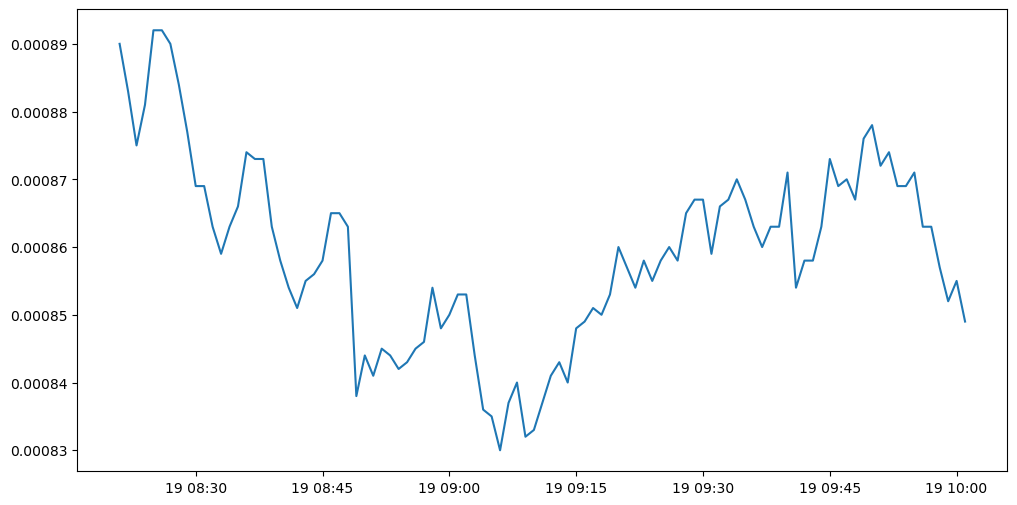

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
x = sushidown_minute['timestamp'].loc[500:600]
y = sushidown_minute['sushidown_price'].loc[500:600]
plt.plot(x,y)